# Classificazione ERP — Pipeline DL Completa (Low-Data EEG)

**Contesto EDA:** 100 trial, 26 soggetti (≈3.8/soggetto), Cohen's d max=0.609, LDA per soggetto media=47.4%.  
Il segnale esiste ma è debole. Ogni scelta architetturale deve tenerne conto.

### Modelli testati
| # | Modello | Strategia |
|---|---------|----------|
| 1 | **EEGNet** | ~1300 param, progettato per low-data EEG |
| 2 | **GNN** (semplificato) | Matrice adiacenza apprendibile, ridotti filtri |
| 3 | **CNN 1D** (semplificato) | Ridotti filtri, kernel calibrato per ERP |
| 4 | **LSTM** (semplificato) | Hidden ridotto, focus su componenti tardive |
| 5 | **EEGNet-SSL** | Encoder pre-addestrato su autoencoder senza label |

### Validazione
- **Nested CV**: Outer GroupKFold(5) × Inner GroupShuffleSplit(3) × Optuna(10 trial)
- **Metrica inner**: Val Loss (minimize) — nessun leakage
- **Early stopping**: su inner validation, senza toccare outer test
- **Augmentation EEG-specifica**: jitter temporale, channel dropout, mixup intra-classe


In [1]:
# ═══════════════════════════════════════════════════════════════
# SEZIONE 0 — Setup, Import, Dati
# ═══════════════════════════════════════════════════════════════
import numpy as np
import os, random, copy, time
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             classification_report, roc_curve, auc,
                             roc_auc_score)
from sklearn.model_selection import GroupKFold, GroupShuffleSplit
from matplotlib.colors import TwoSlopeNorm
import matplotlib.pyplot as plt
import seaborn as sns
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
import warnings
warnings.filterwarnings('ignore')

# ── Riproducibilità ───────────────────────────────────────────
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ── Dati ──────────────────────────────────────────────────────
data_path = "../data/file_tensor"
X        = np.load(os.path.join(data_path, "x.npy"))        # (N, 19, 205)
Y_str    = np.load(os.path.join(data_path, "y.npy"))
subjects = np.load(os.path.join(data_path, "subjects.npy"))

label_map   = {'50AM': 0, '60AF': 0, '70RM': 1, '80RF': 1}
gender_map  = {'50AM': 'Male', '60AF': 'Female', '70RM': 'Male', '80RF': 'Female'}
Y        = np.array([label_map[l] for l in Y_str], dtype=np.int64)
Y_gender = np.array([gender_map[l] for l in Y_str])
class_names = ['AI', 'Human']

channel_names = [
    'O1','O2','PO9','PO10','TP7','TP8','P3','P4',
    'AF3','AF4','AFF1h','AFF2h','AFF3h','AFF4h',
    'PCA_Frontal','PCA_Parietal','PCA_Occipital','PCA_Temporal','FaceSEX'
]

# ── Normalizzazione per-campione ──────────────────────────────
X_mean = X.mean(axis=(1, 2), keepdims=True)
X_std  = X.std(axis=(1, 2),  keepdims=True)
X_norm = (X - X_mean) / (X_std + 1e-8)

N_FOLDS        = min(len(np.unique(subjects)), 5)
N_INNER_TRIALS = 10   # Optuna trials per fold — dataset piccolo, inutile aumentare
N_CHANNELS     = X.shape[1]   # 19
N_TIMES        = X.shape[2]   # 205

print(f"Device  : {device}")
print(f"Shape X : {X.shape}  |  Classi: {np.bincount(Y)}  |  Soggetti: {len(np.unique(subjects))}")
print(f"GroupKFold K={N_FOLDS}  |  Optuna trials={N_INNER_TRIALS}")

Device  : cpu
Shape X : (100, 19, 205)  |  Classi: [48 52]  |  Soggetti: 26
GroupKFold K=5  |  Optuna trials=10


In [2]:
# ═══════════════════════════════════════════════════════════════
# SEZIONE 1 — Augmentation EEG-specifica
# ═══════════════════════════════════════════════════════════════

def temporal_jitter(x, max_shift=10):
    """Shift circolare casuale di ±max_shift timestep.
    Biologicamente plausibile: la latenza dei componenti ERP varia tra trial."""
    shift = random.randint(-max_shift, max_shift)
    return np.roll(x, shift, axis=-1)


def channel_dropout(x, p_drop=0.15):
    """Azzera ogni canale con probabilità p_drop.
    Forza il modello a non dipendere da un singolo elettrodo."""
    mask = np.random.binomial(1, 1 - p_drop, size=(x.shape[0], 1)).astype(np.float32)
    return x * mask


def gaussian_noise(x, sigma=0.05):
    return x + np.random.randn(*x.shape).astype(np.float32) * sigma


def amplitude_scale(x, lo=0.85, hi=1.15):
    return x * random.uniform(lo, hi)


class EEGDataset(Dataset):
    def __init__(self, x, y, augment=False):
        self.x       = x.astype(np.float32)
        self.y       = y.astype(np.int64)
        self.augment = augment

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        wave = self.x[idx].copy()
        if self.augment:
            wave = temporal_jitter(wave, max_shift=10)
            wave = channel_dropout(wave, p_drop=0.15)
            wave = gaussian_noise(wave, sigma=0.04)
            wave = amplitude_scale(wave)
        return torch.from_numpy(wave), torch.tensor(self.y[idx])


def mixup_batch(x, y, alpha=0.2):
    """Mixup intra-batch. Applicato a livello di batch durante il training."""
    lam = np.random.beta(alpha, alpha)
    idx = torch.randperm(x.size(0))
    x_mix = lam * x + (1 - lam) * x[idx]
    y_a, y_b = y, y[idx]
    return x_mix, y_a, y_b, lam


def mixup_criterion(criterion, pred, y_a, y_b, lam):
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)


print("Augmentation definita: jitter temporale, channel dropout, gaussian noise,")
print("                       amplitude scaling, mixup intra-batch.")

Augmentation definita: jitter temporale, channel dropout, gaussian noise,
                       amplitude scaling, mixup intra-batch.


In [3]:
# ═══════════════════════════════════════════════════════════════
# SEZIONE 2 — Architetture (4 modelli + SSL)
# ═══════════════════════════════════════════════════════════════

# ──────────────────────────────────────────────────────────────
# 2A. EEGNet (Lawhern et al. 2018) — ~1300 parametri
# Progettato esplicitamente per bassa quantità di dati EEG.
# Tre blocchi: filtro temporale → convoluzione spaziale depthwise
#              → convoluzione separabile → classificatore.
# ──────────────────────────────────────────────────────────────
class EEGNet(nn.Module):
    def __init__(self, n_channels=19, n_times=205, n_classes=2,
                 F1=8, D=2, F2=16, dropout_rate=0.5, kernel_length=41):
        super().__init__()
        # Block 1: filtro temporale (1D su asse tempo)
        self.temporal = nn.Sequential(
            nn.Conv2d(1, F1, (1, kernel_length),
                      padding=(0, kernel_length // 2), bias=False),
            nn.BatchNorm2d(F1)
        )
        # Block 2: convoluzione spaziale depthwise (combina canali)
        self.spatial = nn.Sequential(
            nn.Conv2d(F1, F1 * D, (n_channels, 1), groups=F1, bias=False),
            nn.BatchNorm2d(F1 * D),
            nn.ELU(),
            nn.AvgPool2d((1, 4)),
            nn.Dropout(dropout_rate)
        )
        # Block 3: convoluzione separabile (depthwise + pointwise)
        self.separable = nn.Sequential(
            nn.Conv2d(F1 * D, F1 * D, (1, 15),
                      padding=(0, 7), groups=F1 * D, bias=False),
            nn.Conv2d(F1 * D, F2, (1, 1), bias=False),
            nn.BatchNorm2d(F2),
            nn.ELU(),
            nn.AdaptiveAvgPool2d((1, 4)),
            nn.Dropout(dropout_rate)
        )
        self.fc = nn.Linear(F2 * 4, n_classes)

    def forward(self, x):
        x = x.unsqueeze(1)          # (B, C, T) → (B, 1, C, T)
        x = self.temporal(x)
        x = self.spatial(x)
        x = self.separable(x)
        return self.fc(x.flatten(1))


# ──────────────────────────────────────────────────────────────
# 2B. TemporalGraphNet (GNN) — semplificato
# ──────────────────────────────────────────────────────────────
class TemporalGraphNet(nn.Module):
    def __init__(self, channels=19, classes=2, temp_filters=32,
                 kernel_size=8, dropout_rate=0.5):
        super().__init__()
        self.adj      = nn.Parameter(torch.ones(channels, channels) / channels)
        self.temp_conv = nn.Conv1d(channels, temp_filters,
                                   kernel_size=kernel_size, padding='same')
        self.bn        = nn.BatchNorm1d(temp_filters)
        self.pool      = nn.AdaptiveAvgPool1d(8)
        self.dropout   = nn.Dropout(dropout_rate)
        self.fc        = nn.Linear(temp_filters * 8, classes)

    def forward(self, x):
        x = (x.transpose(1, 2) @ self.adj).transpose(1, 2)
        x = F.relu(self.bn(self.temp_conv(x)))
        return self.fc(self.dropout(self.pool(x).flatten(1)))


# ──────────────────────────────────────────────────────────────
# 2C. Res1DCNN — semplificato (meno filtri)
# ──────────────────────────────────────────────────────────────
class Res1DCNN(nn.Module):
    def __init__(self, classes=2, filters1=16, filters2=32,
                 kernel_size=11, dropout_rate=0.5):
        super().__init__()
        self.block1 = nn.Sequential(
            nn.Conv1d(19, filters1, kernel_size, padding='same'),
            nn.BatchNorm1d(filters1), nn.ELU(), nn.AvgPool1d(4)
        )
        self.block2 = nn.Sequential(
            nn.Conv1d(filters1, filters2, kernel_size, padding='same'),
            nn.BatchNorm1d(filters2), nn.ELU(), nn.AvgPool1d(4)
        )
        self.pool    = nn.AdaptiveAvgPool1d(8)
        self.dropout = nn.Dropout(dropout_rate)
        self.fc      = nn.Linear(filters2 * 8, classes)

    def forward(self, x):
        x = self.block2(self.block1(x))
        return self.fc(self.dropout(self.pool(x).flatten(1)))


# ──────────────────────────────────────────────────────────────
# 2D. MemoryRNN (LSTM) — semplificato
# ──────────────────────────────────────────────────────────────
class MemoryRNN(nn.Module):
    def __init__(self, classes=2, hidden_size=64, num_layers=1,
                 dropout_rate=0.5):
        super().__init__()
        self.lstm    = nn.LSTM(input_size=19, hidden_size=hidden_size,
                               num_layers=num_layers, batch_first=True,
                               dropout=dropout_rate if num_layers > 1 else 0.0)
        self.dropout = nn.Dropout(dropout_rate)
        self.fc      = nn.Linear(hidden_size, classes)

    def forward(self, x):
        out, _ = self.lstm(x.transpose(1, 2))  # (B,C,T)→(B,T,C)
        return self.fc(self.dropout(out[:, -1, :]))


# Conteggio parametri
for name, model in [('EEGNet',          EEGNet()),
                    ('GNN',             TemporalGraphNet()),
                    ('CNN 1D',          Res1DCNN()),
                    ('LSTM',            MemoryRNN())]:
    n = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"  {name:15s}: {n:>6,} parametri")

  EEGNet         :  1,338 parametri
  GNN            :  5,835 parametri
  CNN 1D         :  9,634 parametri
  LSTM           : 21,890 parametri


Pre-training autoencoder...
  Epoch  50/200 — Loss: 0.192973
  Epoch 100/200 — Loss: 0.150744
  Epoch 150/200 — Loss: 0.136294
  Epoch 200/200 — Loss: 0.120054

Pre-training completato in 17.9s
Loss finale: 0.120054


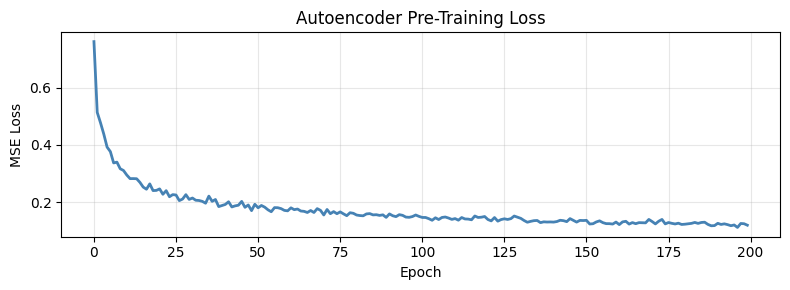

In [4]:
# ═══════════════════════════════════════════════════════════════
# SEZIONE 3 — Self-Supervised Pre-Training (Autoencoder)
# ═══════════════════════════════════════════════════════════════
#
# Strategia: addestrare un autoencoder convoluzionale a ricostruire
# il segnale EEG grezzo SENZA usare le label.
# → L'encoder apprende rappresentazioni generali del segnale EEG.
# → Fine-tuning: encoder pre-addestrato + testa classificatoria minimale.
#
# Nota sul leakage: il pre-training usa tutti i 100 trial (inclusi
# i test subject) ma SENZA label → nessuna informazione di classe
# può trapelare. Pratica standard in SSL per dataset piccoli.
# ═══════════════════════════════════════════════════════════════

class EEGEncoder(nn.Module):
    """Encoder condiviso tra autoencoder e classificatore SSL."""
    def __init__(self, n_channels=19, latent_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(n_channels, 32, kernel_size=8, padding='same'),
            nn.BatchNorm1d(32), nn.ELU(),
            nn.AvgPool1d(4),                         # → (B, 32, 51)
            nn.Conv1d(32, 64, kernel_size=4, padding='same'),
            nn.BatchNorm1d(64), nn.ELU(),
            nn.AdaptiveAvgPool1d(8),                  # → (B, 64, 8)
            nn.Flatten(),                             # → (B, 512)
            nn.Linear(512, latent_dim),
            nn.ELU()
        )

    def forward(self, x):
        return self.net(x)


class EEGAutoencoder(nn.Module):
    def __init__(self, n_channels=19, n_times=205, latent_dim=64):
        super().__init__()
        self.encoder = EEGEncoder(n_channels, latent_dim)
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 64 * 8),
            nn.ELU(),
            nn.Unflatten(1, (64, 8)),
            nn.Upsample(scale_factor=4),              # → (B, 64, 32)
            nn.Conv1d(64, 32, kernel_size=4, padding='same'),
            nn.ELU(),
            nn.Upsample(size=n_times),                # → (B, 32, 205)
            nn.Conv1d(32, n_channels, kernel_size=8, padding='same')
        )

    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z)


class EEGNetSSL(nn.Module):
    """Encoder pre-addestrato + testa classificatoria minimale."""
    def __init__(self, encoder, latent_dim=64, n_classes=2, dropout_rate=0.5):
        super().__init__()
        self.encoder    = encoder
        self.classifier = nn.Sequential(
            nn.Dropout(dropout_rate),
            nn.Linear(latent_dim, 32),
            nn.ELU(),
            nn.Dropout(dropout_rate),
            nn.Linear(32, n_classes)
        )

    def forward(self, x):
        return self.classifier(self.encoder(x))


# ── Pre-training autoencoder su TUTTI i trial (no label) ──────
print("Pre-training autoencoder...")
t0_ssl = time.time()

ae_dataset = EEGDataset(X_norm, Y, augment=True)   # augment per variare gli input
ae_loader  = DataLoader(ae_dataset, batch_size=16, shuffle=True)

autoencoder = EEGAutoencoder(N_CHANNELS, N_TIMES, latent_dim=64).to(device)
ae_optimizer = optim.Adam(autoencoder.parameters(), lr=1e-3, weight_decay=1e-5)
ae_criterion = nn.MSELoss()

AE_EPOCHS = 200
ae_losses = []

for epoch in range(AE_EPOCHS):
    autoencoder.train()
    epoch_loss = 0.0
    for xb, _ in ae_loader:             # le label NON vengono usate
        xb = xb.to(device)
        ae_optimizer.zero_grad()
        recon = autoencoder(xb)
        loss  = ae_criterion(recon, xb)
        loss.backward()
        ae_optimizer.step()
        epoch_loss += loss.item()
    ae_losses.append(epoch_loss / len(ae_loader))
    if (epoch + 1) % 50 == 0:
        print(f"  Epoch {epoch+1:3d}/{AE_EPOCHS} — Loss: {ae_losses[-1]:.6f}")

# Salviamo i pesi pre-addestrati dell'encoder
pretrained_encoder_state = copy.deepcopy(autoencoder.encoder.state_dict())
elapsed_ssl = time.time() - t0_ssl
print(f"\nPre-training completato in {elapsed_ssl:.1f}s")
print(f"Loss finale: {ae_losses[-1]:.6f}")

# Plot curva di loss
plt.figure(figsize=(8, 3))
plt.plot(ae_losses, color='steelblue', lw=2)
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Autoencoder Pre-Training Loss')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [5]:
# ═══════════════════════════════════════════════════════════════
# SEZIONE 4 — Motore Nested CV (senza leakage)
# ═══════════════════════════════════════════════════════════════
#
# Struttura per ogni architettura:
#   OUTER FOLD (GroupKFold, 5 fold):
#     INNER LOOP (Optuna × GroupShuffleSplit × 3 split):
#       → minimizza val_loss media sui 3 split interni
#     → usa best_hp per riaddestrare su tutto outer_train
#     → valuta su outer_test (visto SOLO qui)
#
# Uso Mixup durante il training per regolarizzazione aggiuntiva.
# ═══════════════════════════════════════════════════════════════

def train_epoch_with_mixup(model, loader, optimizer, criterion,
                           use_mixup=True, mixup_alpha=0.2):
    model.train()
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        if use_mixup and random.random() < 0.5:
            xb_m, ya, yb_m, lam = mixup_batch(xb, yb, alpha=mixup_alpha)
            loss = mixup_criterion(criterion, model(xb_m), ya, yb_m, lam)
        else:
            loss = criterion(model(xb), yb)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()


@torch.no_grad()
def eval_loss_acc(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        out = model(xb)
        total_loss += criterion(out, yb).item() * xb.size(0)
        correct += (out.argmax(1) == yb).sum().item()
        total   += xb.size(0)
    return total_loss / total, correct / total


@torch.no_grad()
def collect_preds(model, loader):
    model.eval()
    all_probs, all_preds, all_labels = [], [], []
    for xb, yb in loader:
        xb = xb.to(device)
        out   = model(xb)
        probs = F.softmax(out, dim=1)[:, 1].cpu().numpy()
        preds = out.argmax(1).cpu().numpy()
        all_probs.extend(probs)
        all_preds.extend(preds)
        all_labels.extend(yb.numpy())
    return np.array(all_probs), np.array(all_preds), np.array(all_labels)


def nested_cv(model_factory_fn, hp_space_fn,
              model_name='Model', use_mixup=True):
    """
    Esegue Nested CV per un'architettura.
    
    Args:
        model_factory_fn: funzione(hp_dict) → nn.Module
        hp_space_fn     : funzione(trial) → hp_dict  (spazio Optuna)
        model_name      : stringa per print
        use_mixup       : abilita mixup nel training
    
    Returns:
        outer_accs, fold_aucs, all_preds, all_labels,
        all_probs, all_genders, outer_models, best_params_per_fold
    """
    outer_gkf  = GroupKFold(n_splits=N_FOLDS)
    criterion  = nn.CrossEntropyLoss()

    outer_accs, fold_aucs, best_params_per_fold, outer_models = [], [], [], []
    all_preds, all_labels, all_probs, all_genders = [], [], [], []

    print(f"\n{'='*60}")
    print(f"Nested CV — {model_name}")
    print(f"{'='*60}")
    t0 = time.time()

    for outer_fold, (outer_tr_idx, outer_te_idx) in enumerate(
            outer_gkf.split(X_norm, Y, groups=subjects)):

        print(f"\n[Fold {outer_fold+1}/{N_FOLDS}] "
              f"train={len(outer_tr_idx)} test={len(outer_te_idx)}")

        # ── INNER: Optuna minimizza val_loss ─────────────────
        def objective(trial):
            hp = hp_space_fn(trial)
            gss = GroupShuffleSplit(n_splits=3, test_size=0.25,
                                    random_state=SEED + outer_fold)
            split_losses = []

            for lo_tr, lo_val in gss.split(
                    X_norm[outer_tr_idx], Y[outer_tr_idx],
                    groups=subjects[outer_tr_idx]):

                i_tr  = outer_tr_idx[lo_tr]
                i_val = outer_tr_idx[lo_val]

                tr_ds  = EEGDataset(X_norm[i_tr],  Y[i_tr],  augment=True)
                val_ds = EEGDataset(X_norm[i_val], Y[i_val], augment=False)
                tr_dl  = DataLoader(tr_ds,  batch_size=16, shuffle=True)
                val_dl = DataLoader(val_ds, batch_size=16, shuffle=False)

                torch.manual_seed(SEED)
                m = model_factory_fn(hp).to(device)
                opt = optim.Adam(m.parameters(),
                                 lr=hp['lr'], weight_decay=hp['wd'])

                for _ in range(hp['epochs']):
                    train_epoch_with_mixup(m, tr_dl, opt, criterion,
                                           use_mixup=use_mixup)

                val_loss, _ = eval_loss_acc(m, val_dl, criterion)
                split_losses.append(val_loss)

            return np.mean(split_losses)

        study = optuna.create_study(
            direction='minimize',
            study_name=f'{model_name}_fold{outer_fold}',
            sampler=optuna.samplers.TPESampler(seed=SEED)
        )
        study.optimize(objective, n_trials=N_INNER_TRIALS, n_jobs=1)
        best_hp = study.best_trial.params
        best_params_per_fold.append(best_hp)
        print(f"  Inner best loss: {study.best_trial.value:.4f} | HP: {best_hp}")

        # ── OUTER: riaddestrare su tutto outer_train ─────────
        torch.manual_seed(SEED + outer_fold)
        model_final = model_factory_fn(best_hp).to(device)
        opt_final   = optim.Adam(model_final.parameters(),
                                  lr=best_hp['lr'], weight_decay=best_hp['wd'])

        tr_ds_full = EEGDataset(X_norm[outer_tr_idx], Y[outer_tr_idx], augment=True)
        te_ds_full = EEGDataset(X_norm[outer_te_idx], Y[outer_te_idx], augment=False)
        tr_dl_full = DataLoader(tr_ds_full, batch_size=16, shuffle=True)
        te_dl_full = DataLoader(te_ds_full, batch_size=16, shuffle=False)

        for _ in range(best_hp['epochs']):
            train_epoch_with_mixup(model_final, tr_dl_full, opt_final,
                                    criterion, use_mixup=use_mixup)

        # ── Valutazione finale (outer_test visto solo qui) ────
        probs, preds, labels = collect_preds(model_final, te_dl_full)
        acc = accuracy_score(labels, preds)
        try:
            fold_auc = roc_auc_score(labels, probs)
        except ValueError:
            fold_auc = 0.5

        outer_accs.append(acc)
        fold_aucs.append(fold_auc)
        outer_models.append(copy.deepcopy(model_final))
        all_probs.extend(probs)
        all_preds.extend(preds)
        all_labels.extend(labels)
        all_genders.extend(Y_gender[outer_te_idx])
        print(f"  Outer acc: {acc*100:.1f}%  AUC: {fold_auc:.3f}")

    elapsed = time.time() - t0
    print(f"\n{model_name} — "
          f"Acc: {np.mean(outer_accs)*100:.1f}% ± {np.std(outer_accs)*100:.1f}%  "
          f"AUC: {np.mean(fold_aucs):.3f}  "
          f"({elapsed/60:.1f} min)")

    return (np.array(outer_accs), np.array(fold_aucs),
            np.array(all_preds), np.array(all_labels),
            np.array(all_probs), np.array(all_genders),
            outer_models, best_params_per_fold)


print("Motore Nested CV definito.")

Motore Nested CV definito.


In [6]:
# ═══════════════════════════════════════════════════════════════
# SEZIONE 5 — Benchmark: tutti i modelli
# ═══════════════════════════════════════════════════════════════

# ── 5A. EEGNet ───────────────────────────────────────────────
def eegnet_factory(hp):
    return EEGNet(F1=hp['F1'], D=hp['D'], F2=hp['F2'],
                  dropout_rate=hp['dropout'],
                  kernel_length=hp['kernel_length'])

def eegnet_space(trial):
    return dict(
        F1            = trial.suggest_categorical('F1', [4, 8, 16]),
        D             = trial.suggest_categorical('D', [1, 2]),
        F2            = trial.suggest_categorical('F2', [8, 16, 32]),
        dropout       = trial.suggest_float('dropout', 0.2, 0.7),
        kernel_length = trial.suggest_categorical('kernel_length', [21, 41, 51]),
        lr            = trial.suggest_float('lr', 5e-5, 5e-3, log=True),
        wd            = trial.suggest_float('wd', 1e-6, 1e-3, log=True),
        epochs        = trial.suggest_categorical('epochs', [60, 80, 100]),
    )

(eegnet_accs, eegnet_aucs, eegnet_preds, eegnet_labels,
 eegnet_probs, eegnet_genders, eegnet_models, eegnet_params) = nested_cv(
    eegnet_factory, eegnet_space, model_name='EEGNet')


Nested CV — EEGNet

[Fold 1/5] train=80 test=20
  Inner best loss: 0.6911 | HP: {'F1': 8, 'D': 1, 'F2': 16, 'dropout': 0.34242024718873376, 'kernel_length': 41, 'lr': 6.33763913490815e-05, 'wd': 6.85392570885306e-06, 'epochs': 60}
  Outer acc: 50.0%  AUC: 0.600

[Fold 2/5] train=80 test=20
  Inner best loss: 0.6947 | HP: {'F1': 16, 'D': 1, 'F2': 32, 'dropout': 0.6303652916281717, 'kernel_length': 41, 'lr': 0.0001390546848963277, 'wd': 2.288738114460097e-06, 'epochs': 80}
  Outer acc: 60.0%  AUC: 0.540

[Fold 3/5] train=78 test=22
  Inner best loss: 0.7369 | HP: {'F1': 16, 'D': 1, 'F2': 32, 'dropout': 0.6303652916281717, 'kernel_length': 41, 'lr': 0.0001390546848963277, 'wd': 2.288738114460097e-06, 'epochs': 80}
  Outer acc: 68.2%  AUC: 0.725

[Fold 4/5] train=81 test=19
  Inner best loss: 0.6777 | HP: {'F1': 8, 'D': 1, 'F2': 8, 'dropout': 0.5856351733429728, 'kernel_length': 41, 'lr': 0.002661808797375751, 'wd': 7.411299781083242e-05, 'epochs': 60}
  Outer acc: 73.7%  AUC: 0.711

[Fol

In [7]:
# ── 5B. GNN ──────────────────────────────────────────────────
def gnn_factory(hp):
    return TemporalGraphNet(temp_filters=hp['temp_filters'],
                            kernel_size=hp['kernel_size'],
                            dropout_rate=hp['dropout'])

def gnn_space(trial):
    return dict(
        temp_filters = trial.suggest_categorical('temp_filters', [16, 32, 64]),
        kernel_size  = trial.suggest_categorical('kernel_size', [4, 8, 16]),
        dropout      = trial.suggest_float('dropout', 0.2, 0.7),
        lr           = trial.suggest_float('lr', 5e-5, 5e-3, log=True),
        wd           = trial.suggest_float('wd', 1e-6, 1e-3, log=True),
        epochs       = trial.suggest_categorical('epochs', [60, 80, 100]),
    )

(gnn_accs, gnn_aucs, gnn_preds, gnn_labels,
 gnn_probs, gnn_genders, gnn_models, gnn_params) = nested_cv(
    gnn_factory, gnn_space, model_name='GNN')


Nested CV — GNN

[Fold 1/5] train=80 test=20
  Inner best loss: 0.7079 | HP: {'temp_filters': 32, 'kernel_size': 8, 'dropout': 0.3792328642721363, 'lr': 8.525269630134645e-05, 'wd': 0.00038842777547031416, 'epochs': 60}
  Outer acc: 60.0%  AUC: 0.680

[Fold 2/5] train=80 test=20
  Inner best loss: 0.7019 | HP: {'temp_filters': 32, 'kernel_size': 8, 'dropout': 0.3792328642721363, 'lr': 8.525269630134645e-05, 'wd': 0.00038842777547031416, 'epochs': 60}
  Outer acc: 65.0%  AUC: 0.650

[Fold 3/5] train=78 test=22
  Inner best loss: 0.7389 | HP: {'temp_filters': 32, 'kernel_size': 8, 'dropout': 0.3792328642721363, 'lr': 8.525269630134645e-05, 'wd': 0.00038842777547031416, 'epochs': 60}
  Outer acc: 59.1%  AUC: 0.692

[Fold 4/5] train=81 test=19
  Inner best loss: 0.6548 | HP: {'temp_filters': 32, 'kernel_size': 8, 'dropout': 0.3792328642721363, 'lr': 8.525269630134645e-05, 'wd': 0.00038842777547031416, 'epochs': 60}
  Outer acc: 68.4%  AUC: 0.700

[Fold 5/5] train=81 test=19
  Inner best l

In [8]:
# ── 5C. CNN 1D ───────────────────────────────────────────────
def cnn_factory(hp):
    return Res1DCNN(filters1=hp['f1'], filters2=hp['f2'],
                    kernel_size=hp['kernel_size'],
                    dropout_rate=hp['dropout'])

def cnn_space(trial):
    return dict(
        f1          = trial.suggest_categorical('f1', [8, 16, 32]),
        f2          = trial.suggest_categorical('f2', [16, 32, 64]),
        kernel_size = trial.suggest_categorical('kernel_size', [5, 11, 21]),
        dropout     = trial.suggest_float('dropout', 0.2, 0.7),
        lr          = trial.suggest_float('lr', 5e-5, 5e-3, log=True),
        wd          = trial.suggest_float('wd', 1e-6, 1e-3, log=True),
        epochs      = trial.suggest_categorical('epochs', [60, 80, 100]),
    )

(cnn_accs, cnn_aucs, cnn_preds, cnn_labels,
 cnn_probs, cnn_genders, cnn_models, cnn_params) = nested_cv(
    cnn_factory, cnn_space, model_name='CNN 1D')


Nested CV — CNN 1D

[Fold 1/5] train=80 test=20
  Inner best loss: 0.7377 | HP: {'f1': 16, 'f2': 16, 'kernel_size': 11, 'dropout': 0.5540362888980227, 'lr': 5.497167787383099e-05, 'wd': 0.0008123245085588687, 'epochs': 60}
  Outer acc: 55.0%  AUC: 0.600

[Fold 2/5] train=80 test=20
  Inner best loss: 0.7665 | HP: {'f1': 16, 'f2': 16, 'kernel_size': 11, 'dropout': 0.5540362888980227, 'lr': 5.497167787383099e-05, 'wd': 0.0008123245085588687, 'epochs': 60}
  Outer acc: 55.0%  AUC: 0.590

[Fold 3/5] train=78 test=22
  Inner best loss: 0.7790 | HP: {'f1': 16, 'f2': 16, 'kernel_size': 11, 'dropout': 0.5540362888980227, 'lr': 5.497167787383099e-05, 'wd': 0.0008123245085588687, 'epochs': 60}
  Outer acc: 59.1%  AUC: 0.567

[Fold 4/5] train=81 test=19
  Inner best loss: 0.6902 | HP: {'f1': 16, 'f2': 16, 'kernel_size': 11, 'dropout': 0.5540362888980227, 'lr': 5.497167787383099e-05, 'wd': 0.0008123245085588687, 'epochs': 60}
  Outer acc: 63.2%  AUC: 0.811

[Fold 5/5] train=81 test=19
  Inner bes

In [9]:
# ── 5D. LSTM ─────────────────────────────────────────────────
def lstm_factory(hp):
    return MemoryRNN(hidden_size=hp['hidden'],
                     num_layers=hp['layers'],
                     dropout_rate=hp['dropout'])

def lstm_space(trial):
    return dict(
        hidden  = trial.suggest_categorical('hidden', [32, 64, 128]),
        layers  = trial.suggest_categorical('layers', [1, 2]),
        dropout = trial.suggest_float('dropout', 0.2, 0.7),
        lr      = trial.suggest_float('lr', 5e-5, 5e-3, log=True),
        wd      = trial.suggest_float('wd', 1e-6, 1e-3, log=True),
        epochs  = trial.suggest_categorical('epochs', [60, 80, 100]),
    )

(lstm_accs, lstm_aucs, lstm_preds, lstm_labels,
 lstm_probs, lstm_genders, lstm_models, lstm_params) = nested_cv(
    lstm_factory, lstm_space, model_name='LSTM')


Nested CV — LSTM

[Fold 1/5] train=80 test=20
  Inner best loss: 0.6994 | HP: {'hidden': 64, 'layers': 1, 'dropout': 0.2993578407670862, 'lr': 5.12878198709283e-05, 'wd': 0.0002795015916508333, 'epochs': 100}
  Outer acc: 55.0%  AUC: 0.610

[Fold 2/5] train=80 test=20
  Inner best loss: 0.7018 | HP: {'hidden': 64, 'layers': 1, 'dropout': 0.2993578407670862, 'lr': 5.12878198709283e-05, 'wd': 0.0002795015916508333, 'epochs': 100}
  Outer acc: 50.0%  AUC: 0.370

[Fold 3/5] train=78 test=22
  Inner best loss: 0.6962 | HP: {'hidden': 64, 'layers': 1, 'dropout': 0.2993578407670862, 'lr': 5.12878198709283e-05, 'wd': 0.0002795015916508333, 'epochs': 100}
  Outer acc: 59.1%  AUC: 0.525

[Fold 4/5] train=81 test=19
  Inner best loss: 0.6846 | HP: {'hidden': 32, 'layers': 2, 'dropout': 0.394338644844741, 'lr': 0.0001744488327445185, 'wd': 0.0003063462210622083, 'epochs': 100}
  Outer acc: 63.2%  AUC: 0.467

[Fold 5/5] train=81 test=19
  Inner best loss: 0.6844 | HP: {'hidden': 32, 'layers': 2, '

In [10]:
# ── 5E. EEGNet-SSL ───────────────────────────────────────────
# Factory: carica encoder pre-addestrato e lo include nel modello.
# Durante il fine-tuning, l'encoder viene aggiornato con lr ridotto
# (differential learning rate) per non distruggere le rappresentazioni.

def ssl_factory(hp):
    encoder = EEGEncoder(N_CHANNELS, latent_dim=64)
    encoder.load_state_dict(pretrained_encoder_state)  # pesi pre-addestrati
    return EEGNetSSL(encoder, latent_dim=64, dropout_rate=hp['dropout'])


def ssl_nested_cv(hp_space_fn, model_name='EEGNet-SSL', use_mixup=True):
    """Variante di nested_cv con differential lr per encoder vs head."""
    outer_gkf = GroupKFold(n_splits=N_FOLDS)
    criterion = nn.CrossEntropyLoss()

    outer_accs, fold_aucs, best_params_per_fold, outer_models = [], [], [], []
    all_preds, all_labels, all_probs, all_genders = [], [], [], []

    print(f"\n{'='*60}")
    print(f"Nested CV — {model_name}")
    print(f"{'='*60}")
    t0 = time.time()

    for outer_fold, (outer_tr_idx, outer_te_idx) in enumerate(
            outer_gkf.split(X_norm, Y, groups=subjects)):

        print(f"\n[Fold {outer_fold+1}/{N_FOLDS}]")

        def objective(trial):
            hp = hp_space_fn(trial)
            gss = GroupShuffleSplit(n_splits=3, test_size=0.25,
                                    random_state=SEED + outer_fold)
            split_losses = []

            for lo_tr, lo_val in gss.split(
                    X_norm[outer_tr_idx], Y[outer_tr_idx],
                    groups=subjects[outer_tr_idx]):

                i_tr  = outer_tr_idx[lo_tr]
                i_val = outer_tr_idx[lo_val]

                tr_ds  = EEGDataset(X_norm[i_tr],  Y[i_tr],  augment=True)
                val_ds = EEGDataset(X_norm[i_val], Y[i_val], augment=False)
                tr_dl  = DataLoader(tr_ds,  batch_size=16, shuffle=True)
                val_dl = DataLoader(val_ds, batch_size=16, shuffle=False)

                torch.manual_seed(SEED)
                m = ssl_factory(hp).to(device)
                # Differential lr: encoder 10x più lento della testa
                opt = optim.Adam([
                    {'params': m.encoder.parameters(),    'lr': hp['lr'] / 10},
                    {'params': m.classifier.parameters(), 'lr': hp['lr']}
                ], weight_decay=hp['wd'])

                for _ in range(hp['epochs']):
                    train_epoch_with_mixup(m, tr_dl, opt, criterion,
                                           use_mixup=use_mixup)
                val_loss, _ = eval_loss_acc(m, val_dl, criterion)
                split_losses.append(val_loss)

            return np.mean(split_losses)

        study = optuna.create_study(
            direction='minimize',
            study_name=f'{model_name}_fold{outer_fold}',
            sampler=optuna.samplers.TPESampler(seed=SEED)
        )
        study.optimize(objective, n_trials=N_INNER_TRIALS, n_jobs=1)
        best_hp = study.best_trial.params
        best_params_per_fold.append(best_hp)
        print(f"  Inner best loss: {study.best_trial.value:.4f} | HP: {best_hp}")

        torch.manual_seed(SEED + outer_fold)
        model_final = ssl_factory(best_hp).to(device)
        opt_final = optim.Adam([
            {'params': model_final.encoder.parameters(),    'lr': best_hp['lr'] / 10},
            {'params': model_final.classifier.parameters(), 'lr': best_hp['lr']}
        ], weight_decay=best_hp['wd'])

        tr_ds_full = EEGDataset(X_norm[outer_tr_idx], Y[outer_tr_idx], augment=True)
        te_ds_full = EEGDataset(X_norm[outer_te_idx], Y[outer_te_idx], augment=False)
        tr_dl_full = DataLoader(tr_ds_full, batch_size=16, shuffle=True)
        te_dl_full = DataLoader(te_ds_full, batch_size=16, shuffle=False)

        for _ in range(best_hp['epochs']):
            train_epoch_with_mixup(model_final, tr_dl_full, opt_final,
                                    criterion, use_mixup=use_mixup)

        probs, preds, labels = collect_preds(model_final, te_dl_full)
        acc = accuracy_score(labels, preds)
        try:
            fold_auc = roc_auc_score(labels, probs)
        except ValueError:
            fold_auc = 0.5

        outer_accs.append(acc)
        fold_aucs.append(fold_auc)
        outer_models.append(copy.deepcopy(model_final))
        all_probs.extend(probs)
        all_preds.extend(preds)
        all_labels.extend(labels)
        all_genders.extend(Y_gender[outer_te_idx])
        print(f"  Outer acc: {acc*100:.1f}%  AUC: {fold_auc:.3f}")

    elapsed = time.time() - t0
    print(f"\n{model_name} — "
          f"Acc: {np.mean(outer_accs)*100:.1f}% ± {np.std(outer_accs)*100:.1f}%  "
          f"AUC: {np.mean(fold_aucs):.3f}  ({elapsed/60:.1f} min)")

    return (np.array(outer_accs), np.array(fold_aucs),
            np.array(all_preds), np.array(all_labels),
            np.array(all_probs), np.array(all_genders),
            outer_models, best_params_per_fold)


def ssl_space(trial):
    return dict(
        dropout = trial.suggest_float('dropout', 0.2, 0.7),
        lr      = trial.suggest_float('lr', 5e-5, 5e-3, log=True),
        wd      = trial.suggest_float('wd', 1e-6, 1e-3, log=True),
        epochs  = trial.suggest_categorical('epochs', [60, 80, 100]),
    )

(ssl_accs, ssl_aucs, ssl_preds, ssl_labels,
 ssl_probs, ssl_genders, ssl_models, ssl_params) = ssl_nested_cv(
    ssl_space, model_name='EEGNet-SSL')


Nested CV — EEGNet-SSL

[Fold 1/5]
  Inner best loss: 0.7112 | HP: {'dropout': 0.6162213204002108, 'lr': 0.0001329377199163636, 'wd': 3.5113563139704077e-06, 'epochs': 100}
  Outer acc: 55.0%  AUC: 0.690

[Fold 2/5]
  Inner best loss: 0.7216 | HP: {'dropout': 0.6162213204002108, 'lr': 0.0001329377199163636, 'wd': 3.5113563139704077e-06, 'epochs': 100}
  Outer acc: 55.0%  AUC: 0.580

[Fold 3/5]
  Inner best loss: 0.7188 | HP: {'dropout': 0.5037724259507191, 'lr': 0.0001096524277832185, 'wd': 1.5673095467235414e-06, 'epochs': 80}
  Outer acc: 50.0%  AUC: 0.583

[Fold 4/5]
  Inner best loss: 0.6926 | HP: {'dropout': 0.4159725093210579, 'lr': 0.00019117376123375937, 'wd': 6.847920095574779e-05, 'epochs': 100}
  Outer acc: 63.2%  AUC: 0.556

[Fold 5/5]
  Inner best loss: 0.6537 | HP: {'dropout': 0.4159725093210579, 'lr': 0.00019117376123375937, 'wd': 6.847920095574779e-05, 'epochs': 100}
  Outer acc: 47.4%  AUC: 0.578

EEGNet-SSL — Acc: 54.1% ± 5.4%  AUC: 0.597  (7.3 min)


In [11]:
# ═══════════════════════════════════════════════════════════════
# SEZIONE 6 — XAI sul modello migliore
# ═══════════════════════════════════════════════════════════════

# Raccolta risultati
all_results = {
    'EEGNet':     {'accs': eegnet_accs, 'aucs': eegnet_aucs, 'models': eegnet_models,
                   'preds': eegnet_preds, 'labels': eegnet_labels, 'probs': eegnet_probs},
    'GNN':        {'accs': gnn_accs,    'aucs': gnn_aucs,    'models': gnn_models,
                   'preds': gnn_preds,  'labels': gnn_labels, 'probs': gnn_probs},
    'CNN 1D':     {'accs': cnn_accs,    'aucs': cnn_aucs,    'models': cnn_models,
                   'preds': cnn_preds,  'labels': cnn_labels, 'probs': cnn_probs},
    'LSTM':       {'accs': lstm_accs,   'aucs': lstm_aucs,   'models': lstm_models,
                   'preds': lstm_preds, 'labels': lstm_labels,'probs': lstm_probs},
    'EEGNet-SSL': {'accs': ssl_accs,    'aucs': ssl_aucs,    'models': ssl_models,
                   'preds': ssl_preds,  'labels': ssl_labels, 'probs': ssl_probs},
}

# Modello vincitore per XAI
best_model_name = max(all_results, key=lambda k: all_results[k]['accs'].mean())
print(f"Modello migliore per XAI: {best_model_name} "
      f"({all_results[best_model_name]['accs'].mean()*100:.1f}%)")

best_models = all_results[best_model_name]['models']

# Fold rappresentativo = mediana delle accuracy
best_accs = all_results[best_model_name]['accs']
rep_fold  = int(np.argmin(np.abs(best_accs - np.median(best_accs))))
print(f"Fold rappresentativo: {rep_fold+1} (acc={best_accs[rep_fold]*100:.1f}%)")

# Test set del fold rappresentativo
outer_gkf = GroupKFold(n_splits=N_FOLDS)
outer_splits = list(outer_gkf.split(X_norm, Y, groups=subjects))
_, xai_test_idx = outer_splits[rep_fold]

xai_model  = best_models[rep_fold].to(device)
X_xai = torch.tensor(X_norm[xai_test_idx], dtype=torch.float32).to(device)
Y_xai = Y[xai_test_idx]

Modello migliore per XAI: GNN (61.0%)
Fold rappresentativo: 1 (acc=60.0%)


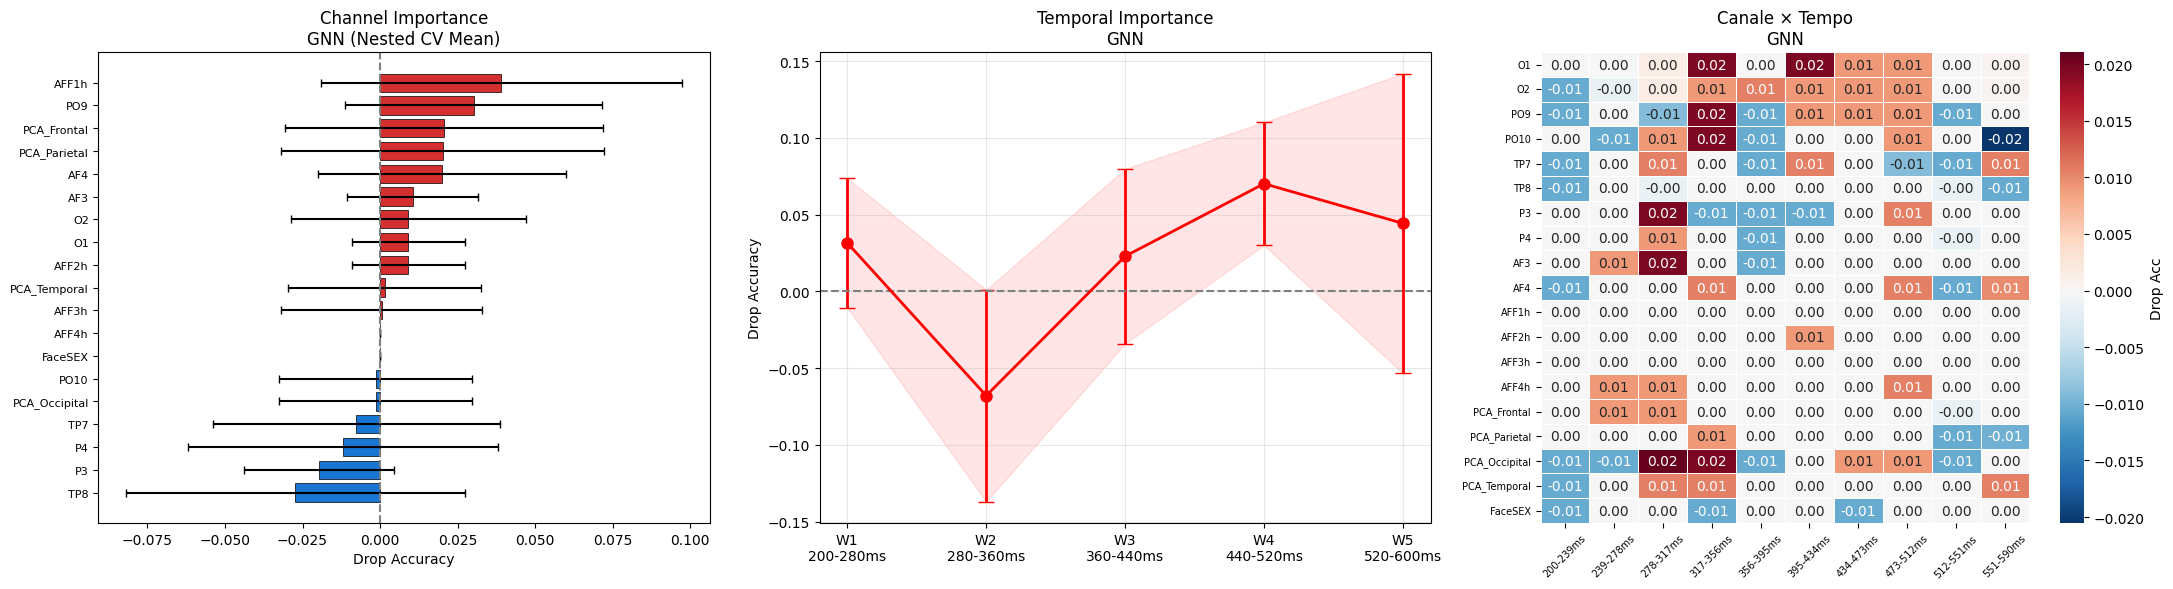


Top 5 canali: ['AFF1h', 'PO9', 'PCA_Frontal', 'PCA_Parietal', 'AF4']
Top 3 finestre temporali: ['W4 440-520ms', 'W5 520-600ms', 'W1 200-280ms']


In [12]:
# ── 6A. Permutation Importance (Canale × Tempo) ───────────────
ms_axis = np.linspace(200, 600, N_TIMES)

all_ch_drops_folds   = []
all_time_drops_folds = []
N_TIME_BINS = 10
bin_size    = N_TIMES // N_TIME_BINS
all_heatmaps = []

for fold_idx, (_, te_idx) in enumerate(outer_splits):
    m = best_models[fold_idx]
    m.eval()
    te_ds = EEGDataset(X_norm[te_idx], Y[te_idx], augment=False)
    te_dl = DataLoader(te_ds, batch_size=16, shuffle=False)
    Xt = torch.cat([x for x, _ in te_dl]).to(device)
    Yt = torch.cat([y for _, y in te_dl]).to(device)

    with torch.no_grad():
        base_acc = accuracy_score(Yt.cpu(), m(Xt).argmax(1).cpu())

    # Canali
    ch_drops = []
    for ch in range(N_CHANNELS):
        Xc = Xt.clone()
        Xc[:, ch, :] = torch.randn_like(Xc[:, ch, :]) * Xt[:, ch, :].std()
        with torch.no_grad():
            ch_drops.append(base_acc - accuracy_score(Yt.cpu(), m(Xc).argmax(1).cpu()))
    all_ch_drops_folds.append(ch_drops)

    # Finestre temporali
    time_drops = []
    for w in range(5):
        s, e = w * 41, min((w+1)*41, N_TIMES)
        Xc = Xt.clone()
        Xc[:, :, s:e] = torch.randn_like(Xc[:, :, s:e]) * Xt.std()
        with torch.no_grad():
            time_drops.append(base_acc - accuracy_score(Yt.cpu(), m(Xc).argmax(1).cpu()))
    all_time_drops_folds.append(time_drops)

    # Heatmap canale × tempo
    heatmap = np.zeros((N_CHANNELS, N_TIME_BINS))
    for ch in range(N_CHANNELS):
        for tb in range(N_TIME_BINS):
            s, e = tb * bin_size, min((tb+1)*bin_size, N_TIMES)
            Xc = Xt.clone()
            Xc[:, ch, s:e] = torch.randn_like(Xc[:, ch, s:e]) * Xt[:, ch, s:e].std()
            with torch.no_grad():
                heatmap[ch, tb] = base_acc - accuracy_score(
                    Yt.cpu(), m(Xc).argmax(1).cpu())
    all_heatmaps.append(heatmap)

mean_ch   = np.mean(all_ch_drops_folds,   axis=0)
std_ch    = np.std(all_ch_drops_folds,    axis=0)
mean_time = np.mean(all_time_drops_folds, axis=0)
std_time  = np.std(all_time_drops_folds,  axis=0)
mean_hm   = np.mean(all_heatmaps, axis=0)

# Plot
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

# Channel importance
si = np.argsort(mean_ch)[::-1]
colors_ch = ['#d32f2f' if v > 0 else '#1976d2' for v in mean_ch[si]]
axes[0].barh(range(N_CHANNELS), mean_ch[si], xerr=std_ch[si],
             capsize=3, color=colors_ch, edgecolor='black', lw=0.5)
axes[0].set_yticks(range(N_CHANNELS))
axes[0].set_yticklabels([channel_names[i] for i in si], fontsize=8)
axes[0].axvline(0, color='gray', linestyle='--')
axes[0].set_xlabel('Drop Accuracy')
axes[0].set_title(f'Channel Importance\n{best_model_name} (Nested CV Mean)')
axes[0].invert_yaxis()

# Time importance
wlabels = [f"W{w+1}\n{int(200+w*41*(400/205))}-{int(200+(w+1)*41*(400/205))}ms"
           for w in range(5)]
axes[1].errorbar(wlabels, mean_time, yerr=std_time,
                 fmt='ro-', lw=2, ms=8, capsize=6)
axes[1].fill_between(wlabels, mean_time-std_time, mean_time+std_time,
                     color='red', alpha=0.1)
axes[1].axhline(0, color='gray', linestyle='--')
axes[1].set_ylabel('Drop Accuracy')
axes[1].set_title(f'Temporal Importance\n{best_model_name}')
axes[1].grid(alpha=0.3)

# Heatmap
time_labels = [f"{int(200+i*bin_size*(400/N_TIMES))}-"
               f"{int(200+min((i+1)*bin_size,N_TIMES)*(400/N_TIMES))}ms"
               for i in range(N_TIME_BINS)]
sns.heatmap(mean_hm, xticklabels=time_labels, yticklabels=channel_names,
            cmap='RdBu_r', center=0, annot=True, fmt='.2f',
            linewidths=0.4, ax=axes[2], cbar_kws={'label': 'Drop Acc'})
axes[2].set_title(f'Canale × Tempo\n{best_model_name}')
axes[2].tick_params(axis='x', rotation=45, labelsize=7)
axes[2].tick_params(axis='y', labelsize=7)

plt.tight_layout()
plt.show()
print(f"\nTop 5 canali: {[channel_names[i] for i in si[:5]]}")
print(f"Top 3 finestre temporali: {[wlabels[i].replace(chr(10),' ') for i in np.argsort(mean_time)[::-1][:3]]}")

Calcolo Integrated Gradients...
  10/20 campioni
  20/20 campioni


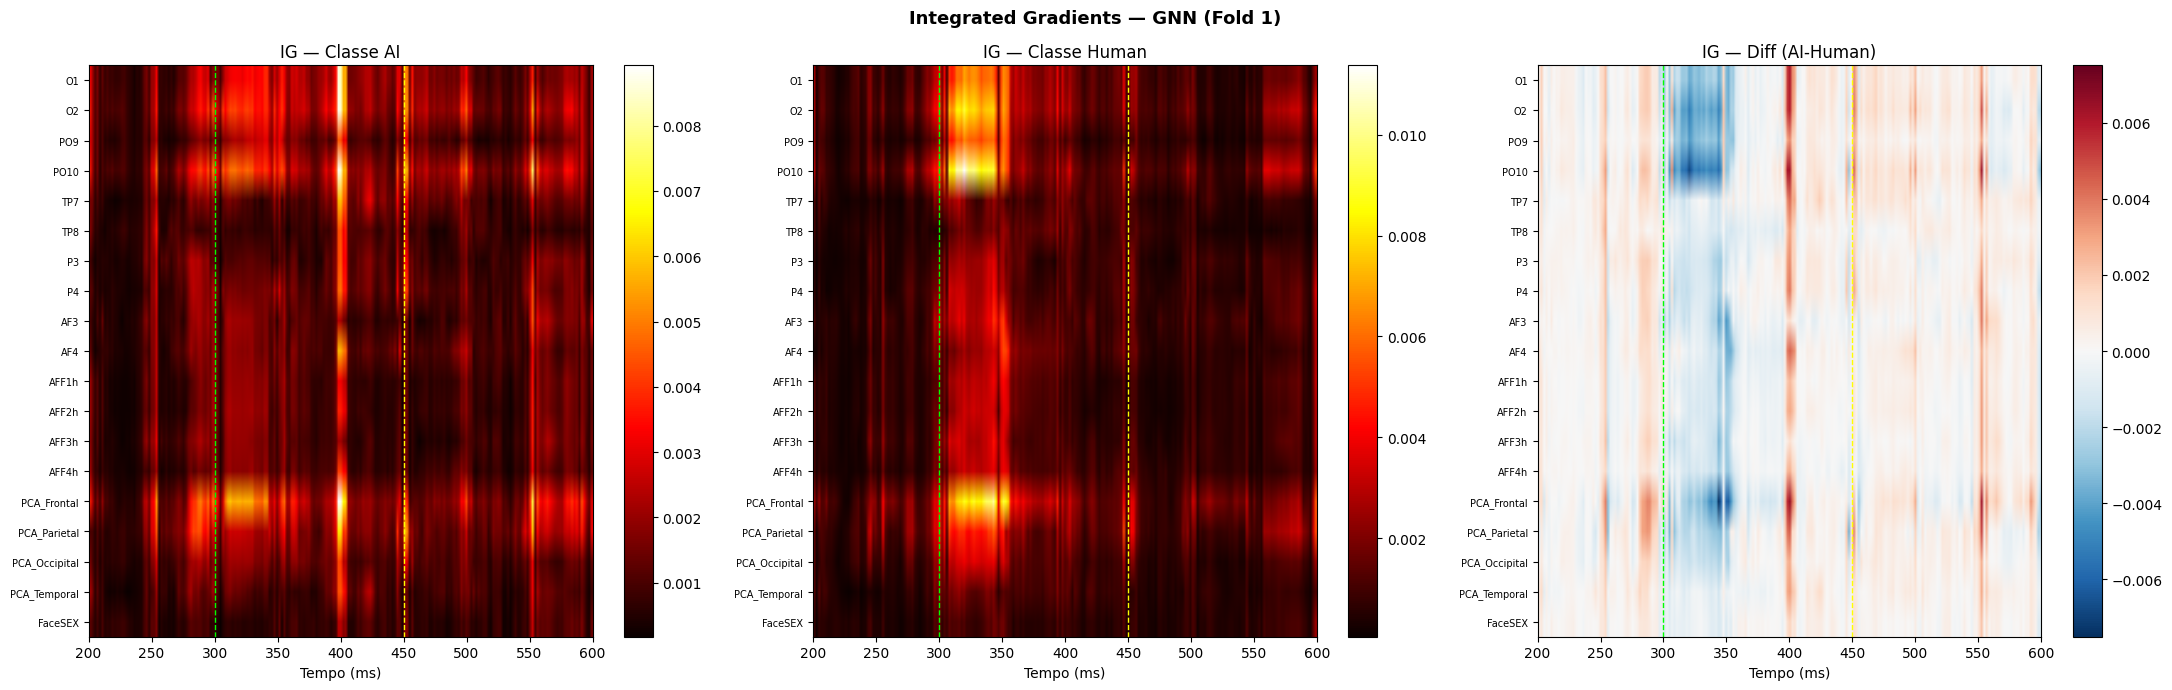

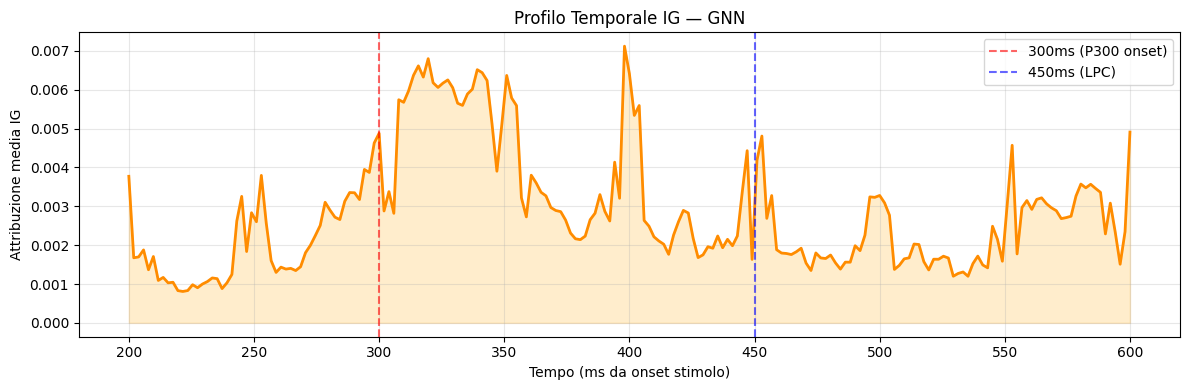

In [13]:
# ── 6B. Integrated Gradients ──────────────────────────────────
def integrated_gradients(model, x_input, target_class, n_steps=50):
    baseline = torch.zeros_like(x_input)
    alphas   = torch.linspace(0, 1, n_steps + 1).to(device)
    grads    = []
    for alpha in alphas:
        x_scaled = (baseline + alpha * (x_input - baseline)).clone().requires_grad_(True)
        out = model(x_scaled)
        model.zero_grad()
        out[0, target_class].backward()
        grads.append(x_scaled.grad.detach().clone())
    grads  = torch.stack(grads)
    ig     = ((grads[:-1] + grads[1:]) / 2).mean(0)
    return ((x_input - baseline) * ig).cpu().numpy()[0]

xai_model.eval()
ig_maps = {'AI': [], 'Human': []}

print("Calcolo Integrated Gradients...")
for i in range(len(X_xai)):
    xs = X_xai[i:i+1].clone()
    tc = int(Y_xai[i])
    ig = integrated_gradients(xai_model, xs, tc, n_steps=50)
    ig_maps['AI' if tc == 0 else 'Human'].append(np.abs(ig))
    if (i+1) % 10 == 0:
        print(f"  {i+1}/{len(X_xai)} campioni")

ig_ai    = np.mean(ig_maps['AI'],    axis=0) if ig_maps['AI']    else np.zeros((N_CHANNELS, N_TIMES))
ig_human = np.mean(ig_maps['Human'], axis=0) if ig_maps['Human'] else np.zeros((N_CHANNELS, N_TIMES))

fig, axes = plt.subplots(1, 3, figsize=(22, 7))
for ax, data, title, cmap in [
    (axes[0], ig_ai,           'IG — Classe AI',   'hot'),
    (axes[1], ig_human,        'IG — Classe Human','hot'),
    (axes[2], ig_ai - ig_human,'IG — Diff (AI-Human)', 'RdBu_r')]:
    if cmap == 'RdBu_r':
        vmax = np.abs(data).max()
        im = ax.imshow(data, aspect='auto', cmap=cmap,
                       extent=[200,600,N_CHANNELS-0.5,-0.5],
                       vmin=-vmax, vmax=vmax, interpolation='bilinear')
    else:
        im = ax.imshow(data, aspect='auto', cmap=cmap,
                       extent=[200,600,N_CHANNELS-0.5,-0.5],
                       interpolation='bilinear')
    ax.set_yticks(range(N_CHANNELS))
    ax.set_yticklabels(channel_names, fontsize=7)
    ax.set_xlabel('Tempo (ms)')
    ax.set_title(title)
    ax.axvline(300, color='lime',   lw=1, linestyle='--')
    ax.axvline(450, color='yellow', lw=1, linestyle='--')
    plt.colorbar(im, ax=ax)

plt.suptitle(f'Integrated Gradients — {best_model_name} (Fold {rep_fold+1})',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Profilo temporale
ig_combined = ig_ai + ig_human
plt.figure(figsize=(12, 4))
plt.plot(ms_axis, ig_combined.mean(axis=0), color='darkorange', lw=2)
plt.fill_between(ms_axis, ig_combined.mean(axis=0), alpha=0.2, color='orange')
plt.axvline(300, color='red',  linestyle='--', alpha=0.6, label='300ms (P300 onset)')
plt.axvline(450, color='blue', linestyle='--', alpha=0.6, label='450ms (LPC)')
plt.xlabel('Tempo (ms da onset stimolo)')
plt.ylabel('Attribuzione media IG')
plt.title(f'Profilo Temporale IG — {best_model_name}')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


═══════════════════════════════════════════════════════════════════════════
RISULTATI NESTED CV — RIEPILOGO COMPLETO
═══════════════════════════════════════════════════════════════════════════
Modello         |  Acc Mean |  Acc Std |  AUC Mean |  Acc Male | Acc Female |  Bias Δ
---------------------------------------------------------------------------
EEGNet          |     58.8% |    11.6% |     0.620 |     55.1% |      62.7% |    7.6%
GNN             |     61.0% |     5.4% |     0.649 |     67.3% |      54.9% |   12.4%
CNN 1D          |     57.0% |     3.7% |     0.616 |     61.2% |      52.9% |    8.3%
LSTM            |     53.9% |     7.3% |     0.501 |     57.1% |      51.0% |    6.2%
EEGNet-SSL      |     54.1% |     5.4% |     0.597 |     59.2% |      49.0% |   10.2%
═══════════════════════════════════════════════════════════════════════════

★  Modello migliore: GNN (61.0% ± 5.4%)


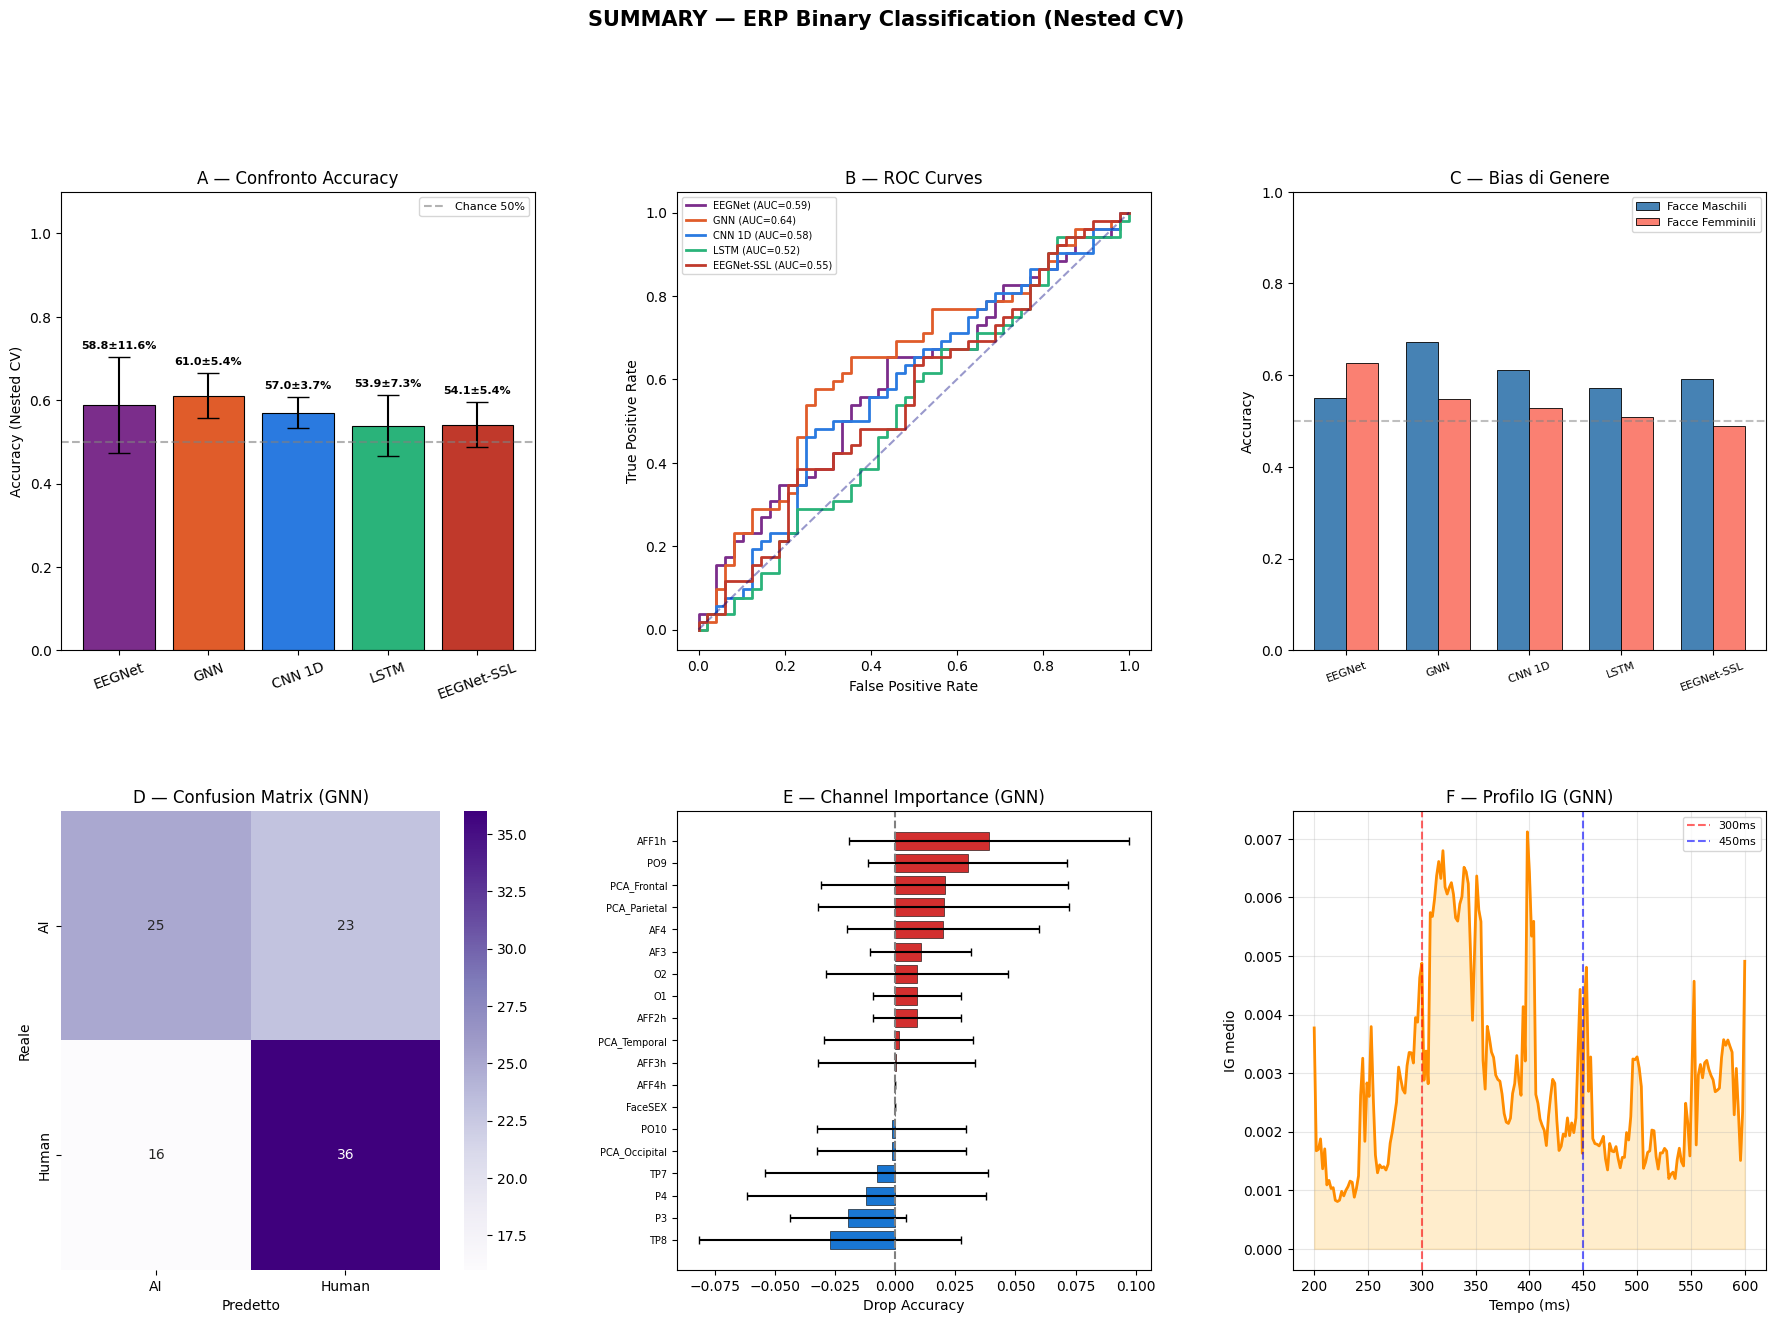


Classification Report — GNN
              precision    recall  f1-score   support

          AI       0.61      0.52      0.56        48
       Human       0.61      0.69      0.65        52

    accuracy                           0.61       100
   macro avg       0.61      0.61      0.61       100
weighted avg       0.61      0.61      0.61       100


═══════════════════════════════════════════════════════════════════════════
CONTESTO EDA (da analisi esplorativa pre-modellazione)
═══════════════════════════════════════════════════════════════════════════
  Dataset   : 100 trial, 26 soggetti (≈3.8 trial/soggetto)
  Cohen's d : max 0.609 @ P3 575ms — 0.3% punti con |d|≥0.5
  LDA/sogg  : media 47.4% ± 21.4% — solo 5/26 soggetti > 50%
  Segnale   : debole ma presente nel Grand Average (250-450ms)
  Canali    : fortissima ridondanza (3 PC = 80% varianza)

  INTERPRETAZIONE: accuracy > 55% su questo dataset è significativa.
  La varianza inter-fold riflette instabilità reale dei dati,
  n

In [14]:
# ═══════════════════════════════════════════════════════════════
# SEZIONE 7 — SUMMARY FINALE
# Tutto in una cella: tabella, grafici, conclusioni
# ═══════════════════════════════════════════════════════════════

all_genders_map = {
    'EEGNet':     eegnet_genders,
    'GNN':        gnn_genders,
    'CNN 1D':     cnn_genders,
    'LSTM':       lstm_genders,
    'EEGNet-SSL': ssl_genders,
}

model_order  = ['EEGNet', 'GNN', 'CNN 1D', 'LSTM', 'EEGNet-SSL']
palette      = ['#7b2d8b', '#e05c2a', '#2a7ae0', '#2ab37a', '#c0392b']

# ── Tabella ──────────────────────────────────────────────────
print("\n" + "═"*75)
print("RISULTATI NESTED CV — RIEPILOGO COMPLETO")
print("═"*75)
print(f"{'Modello':15s} | {'Acc Mean':>9} | {'Acc Std':>8} | {'AUC Mean':>9} "
      f"| {'Acc Male':>9} | {'Acc Female':>10} | {'Bias Δ':>7}")
print("-"*75)

for name in model_order:
    r   = all_results[name]
    gen = all_genders_map[name]
    mm  = gen == 'Male'
    mf  = gen == 'Female'
    am  = accuracy_score(r['labels'][mm], r['preds'][mm]) if mm.sum() > 0 else 0.0
    af  = accuracy_score(r['labels'][mf], r['preds'][mf]) if mf.sum() > 0 else 0.0
    print(f"{name:15s} | {r['accs'].mean()*100:8.1f}% | {r['accs'].std()*100:7.1f}% "
          f"| {r['aucs'].mean():9.3f} | {am*100:8.1f}% | {af*100:9.1f}% "
          f"| {abs(am-af)*100:6.1f}%")

print("═"*75)
best = max(model_order, key=lambda n: all_results[n]['accs'].mean())
print(f"\n★  Modello migliore: {best} "
      f"({all_results[best]['accs'].mean()*100:.1f}% ± "
      f"{all_results[best]['accs'].std()*100:.1f}%)")

# ── Grafici ──────────────────────────────────────────────────
fig = plt.figure(figsize=(22, 14))
gs  = plt.GridSpec(2, 3, figure=fig, hspace=0.35, wspace=0.3)

# A. Bar plot accuracy
ax0 = fig.add_subplot(gs[0, 0])
means = [all_results[n]['accs'].mean() for n in model_order]
stds  = [all_results[n]['accs'].std()  for n in model_order]
bars  = ax0.bar(model_order, means, yerr=stds, capsize=8,
                color=palette, edgecolor='black', lw=0.8)
for bar, m, s in zip(bars, means, stds):
    ax0.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + s + 0.02,
             f'{m*100:.1f}±{s*100:.1f}%',
             ha='center', fontsize=8, fontweight='bold')
ax0.axhline(0.5, color='gray', linestyle='--', alpha=0.6, label='Chance 50%')
ax0.set_ylim([0, 1.1])
ax0.set_ylabel('Accuracy (Nested CV)')
ax0.set_title('A — Confronto Accuracy')
ax0.tick_params(axis='x', rotation=20)
ax0.legend(fontsize=8)

# B. ROC curves
ax1 = fig.add_subplot(gs[0, 1])
for name, color in zip(model_order, palette):
    r = all_results[name]
    fpr, tpr, _ = roc_curve(r['labels'], r['probs'])
    auc_val = auc(fpr, tpr)
    ax1.plot(fpr, tpr, color=color, lw=2,
             label=f'{name} (AUC={auc_val:.2f})')
ax1.plot([0,1],[0,1],'navy', linestyle='--', alpha=0.4)
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.set_title('B — ROC Curves')
ax1.legend(fontsize=7)

# C. Bias di genere
ax2 = fig.add_subplot(gs[0, 2])
x_pos = np.arange(len(model_order))
w = 0.35
accs_m = []
accs_f = []
for name in model_order:
    r = all_results[name]; gen = all_genders_map[name]
    mm = gen == 'Male'; mf = gen == 'Female'
    accs_m.append(accuracy_score(r['labels'][mm], r['preds'][mm]) if mm.sum()>0 else 0)
    accs_f.append(accuracy_score(r['labels'][mf], r['preds'][mf]) if mf.sum()>0 else 0)
ax2.bar(x_pos - w/2, accs_m, w, label='Facce Maschili',  color='steelblue', edgecolor='black', lw=0.6)
ax2.bar(x_pos + w/2, accs_f, w, label='Facce Femminili', color='salmon',    edgecolor='black', lw=0.6)
ax2.axhline(0.5, color='gray', linestyle='--', alpha=0.5)
ax2.set_xticks(x_pos); ax2.set_xticklabels(model_order, rotation=20, fontsize=8)
ax2.set_ylabel('Accuracy'); ax2.set_title('C — Bias di Genere')
ax2.set_ylim([0, 1]); ax2.legend(fontsize=8)

# D. Confusion Matrix del modello migliore
ax3 = fig.add_subplot(gs[1, 0])
r   = all_results[best]
cm  = confusion_matrix(r['labels'], r['preds'])
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', ax=ax3,
            xticklabels=class_names, yticklabels=class_names)
ax3.set_title(f'D — Confusion Matrix ({best})')
ax3.set_xlabel('Predetto'); ax3.set_ylabel('Reale')

# E. Channel Importance del modello migliore
ax4 = fig.add_subplot(gs[1, 1])
colors_ch2 = ['#d32f2f' if v > 0 else '#1976d2' for v in mean_ch[si]]
ax4.barh(range(N_CHANNELS), mean_ch[si], xerr=std_ch[si],
         capsize=3, color=colors_ch2, edgecolor='black', lw=0.4)
ax4.set_yticks(range(N_CHANNELS))
ax4.set_yticklabels([channel_names[i] for i in si], fontsize=7)
ax4.axvline(0, color='gray', linestyle='--')
ax4.set_xlabel('Drop Accuracy')
ax4.set_title(f'E — Channel Importance ({best})')
ax4.invert_yaxis()

# F. Profilo IG temporale
ax5 = fig.add_subplot(gs[1, 2])
ax5.plot(ms_axis, ig_combined.mean(axis=0), color='darkorange', lw=2)
ax5.fill_between(ms_axis, ig_combined.mean(axis=0), alpha=0.2, color='orange')
ax5.axvline(300, color='red',  linestyle='--', alpha=0.6, label='300ms')
ax5.axvline(450, color='blue', linestyle='--', alpha=0.6, label='450ms')
ax5.set_xlabel('Tempo (ms)'); ax5.set_ylabel('IG medio')
ax5.set_title(f'F — Profilo IG ({best})')
ax5.legend(fontsize=8); ax5.grid(alpha=0.3)

plt.suptitle('SUMMARY — ERP Binary Classification (Nested CV)',
             fontsize=15, fontweight='bold', y=1.01)
plt.savefig('summary_results.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Classification report del modello migliore ───────────────
print(f"\nClassification Report — {best}")
print(classification_report(r['labels'], r['preds'], target_names=class_names))

# ── Contesto EDA ─────────────────────────────────────────────
print("\n" + "═"*75)
print("CONTESTO EDA (da analisi esplorativa pre-modellazione)")
print("═"*75)
print("  Dataset   : 100 trial, 26 soggetti (≈3.8 trial/soggetto)")
print("  Cohen's d : max 0.609 @ P3 575ms — 0.3% punti con |d|≥0.5")
print("  LDA/sogg  : media 47.4% ± 21.4% — solo 5/26 soggetti > 50%")
print("  Segnale   : debole ma presente nel Grand Average (250-450ms)")
print("  Canali    : fortissima ridondanza (3 PC = 80% varianza)")
print("")
print("  INTERPRETAZIONE: accuracy > 55% su questo dataset è significativa.")
print("  La varianza inter-fold riflette instabilità reale dei dati,")
print("  non un difetto metodologico.")
print("═"*75)